In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "ev_battery_failure_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sarveshchhetri/ev-battery-failure-prediction-dataset-200k",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df.head()

c:\Users\HP USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\HP USER\AppData\Local\Temp\ipykernel_12928\3376706058.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,...,0.0,3.0,1.0,23.4,32.5,58.2,NaN,NaN,867.0,0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,...,3.0,2.0,1.0,51.2,45.4,51.0,NaN,100.0,1090.0,0


## EDA

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   vehicle_id                       200000 non-null  str    
 1   vehicle_brand                    193564 non-null  str    
 2   vehicle_model                    191796 non-null  str    
 3   vehicle_type                     193568 non-null  str    
 4   manufacturing_year               190171 non-null  float64
 5   battery_manufacturer             193812 non-null  str    
 6   battery_chemistry                192786 non-null  str    
 7   battery_capacity_kwh             193097 non-null  float64
 8   drive_type                       192732 non-null  str    
 9   odometer_km                      191334 non-null  float64
 10  vehicle_age_years                192317 non-null  float64
 11  fleet_or_private                 191050 non-null  str    
 12  battery_seria

In [8]:
num_cols = df.select_dtypes(include='number')
cat_cols = df.select_dtypes(include= 'str')

In [9]:
#check for missing data
df.isnull().sum()

vehicle_id                            0
vehicle_brand                      6436
vehicle_model                      8204
vehicle_type                       6432
manufacturing_year                 9829
                                   ... 
thermal_health_score               6329
charging_quality_score             7186
driving_stress_score               6810
predicted_remaining_life_cycles    8974
battery_failure                       0
Length: 70, dtype: int64

In [10]:
#filling missing data
for col in num_cols.columns:
   df[col]=df[col].fillna(df[col].mean())

for col in cat_cols.columns:
   df[col]=df[col].fillna(df[col].mode()[0])


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   vehicle_id                       200000 non-null  str    
 1   vehicle_brand                    200000 non-null  str    
 2   vehicle_model                    200000 non-null  str    
 3   vehicle_type                     200000 non-null  str    
 4   manufacturing_year               200000 non-null  float64
 5   battery_manufacturer             200000 non-null  str    
 6   battery_chemistry                200000 non-null  str    
 7   battery_capacity_kwh             200000 non-null  float64
 8   drive_type                       200000 non-null  str    
 9   odometer_km                      200000 non-null  float64
 10  vehicle_age_years                200000 non-null  float64
 11  fleet_or_private                 200000 non-null  str    
 12  battery_seria

In [12]:
X=df.drop("battery_failure",axis=1)
y=df["battery_failure"]

In [13]:
y.value_counts()

battery_failure
0    180079
1     19921
Name: count, dtype: int64

In [ ]:
for col in df.columns:
        print(f"{col}")
        print(df[col].nunique())
    

In [ ]:
df.drop(columns=['vehicle_id','vehicle_model','battery_capacity_kwh','odometer_km','vehicle_age_years','battery_serial','cycle_count','battery_health_percent','state_of_charge','depth_of_discharge','state_of_health','cell_voltage_avg','cell_voltage_std','pack_voltage','cell_temperature_avg','cell_temperature_max','internal_resistance','charge_efficiency','discharge_efficiency','remaining_capacity','capacity_loss_percent','fast_charge_ratio','slow_charge_ratio',
'average_charge_power_kw',
'average_charging_time',
'overnight_charging_ratio',
'home_charging_ratio',
'average_speed',
'average_trip_distance',
'aggressive_acceleration_score',
'hard_braking_score',
'regenerative_braking_usage',
'highway_driving_ratio',
'city_driving_ratio',
'daily_distance',
'average_ambient_temperature',
'maximum_temperature',
'minimum_temperature',
'humidity',
'altitude',
'dust_exposure',
'last_service_days',
'cooling_system_health',
'maintenance_score',
'thermal_runaway_risk',
'voltage_imbalance',
'temperature_variance',
'battery_stress_index',
'aging_score',
'thermal_health_score',
'charging_quality_score',
'driving_stress_score',
'predicted_remaining_life_cycles',
'battery_failure'])

,vehicle_brand,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,drive_type,fleet_or_private,charging_cycles_last_month,charging_interruptions,overcharge_events,terrain_type,firmware_updates,previous_faults,sensor_fault_count,BMS_warning_count,abnormal_voltage_events
0,Nissan,SUV,2019.000000,CATL,LMO,RWD,Private,4.0,0.000000,2.0,Flat,2.0,0.0,2.0,3.0,0.0
1,Audi,Sedan,2018.000000,Samsung SDI,NMC,AWD,Private,3.0,0.000000,2.0,Hilly,3.0,0.0,0.0,3.0,0.0
2,Toyota,Van,2018.000000,Guoxuan,NMC,RWD,Fleet,7.0,0.000000,2.0,Flat,3.0,1.0,4.0,1.0,0.0
3,Volkswagen,Hatchback,2022.000000,CATL,NMC,AWD,Private,10.0,0.000000,0.0,Hilly,0.0,0.0,0.0,3.0,1.0
4,Tesla,Crossover,2015.000000,BYD Battery,NMC,FWD,Private,5.0,0.000000,0.0,Coastal,19.0,3.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,BYD,Hatchback,2016.000000,CATL,LFP,FWD,Private,9.0,2.000000,5.0,Flat,12.0,3.0,3.0,1.0,1.0
199996,Lucid,Crossover,2015.000000,LG Energy Solution,NMC,AWD,Private,10.0,0.000000,1.0,Hilly,14.0,2.0,2.0,5.0,2.0
199997,BYD,SUV,2019.501333,BYD Battery,LFP,FWD,Fleet,7.0,1.051767,0.0,Mountainous,3.0,2.0,2.0,2.0,0.0
199998,Tesla,Hatchback,2016.000000,SK On,NMC,FWD,Private,4.0,0.000000,0.0,Coastal,9.0,2.0,2.0,2.0,0.0


In [ ]:
df.describe()

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2019.501333,76.236405,102822.193327,6.495245,296.383934,87.381787,54.847079,38.290397,87.297020,3.288515,...,1.331032,2.024745,0.494595,35.179580,29.912538,63.538378,50.989061,40.948318,1859.485986,0.099605
std,2.801998,20.931475,86038.926637,2.822356,277.155285,12.255904,20.927251,12.486639,12.224026,0.240899,...,1.234972,1.543707,0.715377,21.387294,27.419282,13.544802,27.310967,29.335899,1792.730617,0.299473
min,2015.000000,25.000000,500.000000,1.370000,1.000000,21.420000,2.000000,5.000000,21.800000,2.048500,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,61.560000,37850.000000,4.040000,100.000000,81.650000,40.970000,30.050000,81.630000,3.126400,...,0.000000,1.000000,0.000000,19.800000,7.600000,54.100000,31.700000,16.400000,911.000000,0.000000
50%,2019.501333,76.236405,83446.000000,6.495245,229.000000,90.400000,54.847079,38.290397,90.310000,3.344000,...,1.000000,2.000000,0.000000,34.200000,24.100000,61.800000,52.100000,40.500000,1277.000000,0.000000
75%,2022.000000,89.480000,141873.250000,8.960000,402.000000,97.160000,68.880000,46.460000,97.080000,3.458400,...,2.000000,3.000000,1.000000,47.800000,43.800000,73.200000,72.000000,62.000000,2937.000000,0.000000
max,2024.000000,149.010000,450000.000000,11.550000,3369.000000,99.800000,100.000000,92.030000,100.000000,3.853000,...,10.000000,13.000000,7.000000,100.000000,100.000000,100.000000,100.000000,100.000000,15474.000000,1.000000


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   vehicle_id                       200000 non-null  str    
 1   vehicle_brand                    200000 non-null  str    
 2   vehicle_model                    200000 non-null  str    
 3   vehicle_type                     200000 non-null  str    
 4   manufacturing_year               200000 non-null  float64
 5   battery_manufacturer             200000 non-null  str    
 6   battery_chemistry                200000 non-null  str    
 7   battery_capacity_kwh             200000 non-null  float64
 8   drive_type                       200000 non-null  str    
 9   odometer_km                      200000 non-null  float64
 10  vehicle_age_years                200000 non-null  float64
 11  fleet_or_private                 200000 non-null  str    
 12  battery_seria

## Feature Selection

In [17]:
df.describe()

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2019.501333,76.236405,102822.193327,6.495245,296.383934,87.381787,54.847079,38.290397,87.297020,3.288515,...,1.331032,2.024745,0.494595,35.179580,29.912538,63.538378,50.989061,40.948318,1859.485986,0.099605
std,2.801998,20.931475,86038.926637,2.822356,277.155285,12.255904,20.927251,12.486639,12.224026,0.240899,...,1.234972,1.543707,0.715377,21.387294,27.419282,13.544802,27.310967,29.335899,1792.730617,0.299473
min,2015.000000,25.000000,500.000000,1.370000,1.000000,21.420000,2.000000,5.000000,21.800000,2.048500,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,61.560000,37850.000000,4.040000,100.000000,81.650000,40.970000,30.050000,81.630000,3.126400,...,0.000000,1.000000,0.000000,19.800000,7.600000,54.100000,31.700000,16.400000,911.000000,0.000000
50%,2019.501333,76.236405,83446.000000,6.495245,229.000000,90.400000,54.847079,38.290397,90.310000,3.344000,...,1.000000,2.000000,0.000000,34.200000,24.100000,61.800000,52.100000,40.500000,1277.000000,0.000000
75%,2022.000000,89.480000,141873.250000,8.960000,402.000000,97.160000,68.880000,46.460000,97.080000,3.458400,...,2.000000,3.000000,1.000000,47.800000,43.800000,73.200000,72.000000,62.000000,2937.000000,0.000000
max,2024.000000,149.010000,450000.000000,11.550000,3369.000000,99.800000,100.000000,92.030000,100.000000,3.853000,...,10.000000,13.000000,7.000000,100.000000,100.000000,100.000000,100.000000,100.000000,15474.000000,1.000000


In [18]:
X= df.drop(['battery_failure'],axis=1)
y= df['battery_failure']

In [16]:
correlations = df.corr(numeric_only=True)['battery_failure'].abs().sort_values(ascending=False)


In [19]:
top_35 = correlations.head(36).index.tolist()
top_35.remove('battery_failure')

X = df[top_35]


## Checking for class imbalance


In [35]:
# Check unique values of the selected features
for col in top_35:
    print(col, df[col].nunique())

capacity_loss_percent 6146
battery_health_percent 6143
state_of_health 6171
aging_score 1002
cell_voltage_std 4721
charge_efficiency 1589
cycle_count 1976
odometer_km 129049
voltage_imbalance 6047
charging_quality_score 1002
thermal_runaway_risk 1001
thermal_health_score 795
daily_distance 1709
internal_resistance 9351
charging_cycles_last_month 41
remaining_capacity 11953
average_trip_distance 1188
battery_stress_index 1002
BMS_warning_count 15
cooling_system_health 776
fast_charge_ratio 998
slow_charge_ratio 999
vehicle_age_years 1006
manufacturing_year 11
home_charging_ratio 1002
predicted_remaining_life_cycles 5170
average_charge_power_kw 10644
previous_faults 13
discharge_efficiency 2114
overnight_charging_ratio 869
average_charging_time 5557
firmware_updates 31
cell_voltage_avg 11585
cell_temperature_avg 7233
temperature_variance 2691


In [36]:
# Drop features with plenty of unique values (high cardinality)
# so the plots below remain readable
HIGH_CARD_LIMIT = 50

plot_features = [col for col in top_35 if df[col].nunique() <= HIGH_CARD_LIMIT]
dropped_features = [col for col in top_35 if df[col].nunique() > HIGH_CARD_LIMIT]

print('Dropped (too many unique values):', dropped_features)
print('Kept for plotting:', len(plot_features), 'features')

Dropped (too many unique values): ['capacity_loss_percent', 'battery_health_percent', 'state_of_health', 'aging_score', 'cell_voltage_std', 'charge_efficiency', 'cycle_count', 'odometer_km', 'voltage_imbalance', 'charging_quality_score', 'thermal_runaway_risk', 'thermal_health_score', 'daily_distance', 'internal_resistance', 'remaining_capacity', 'average_trip_distance', 'battery_stress_index', 'cooling_system_health', 'fast_charge_ratio', 'slow_charge_ratio', 'vehicle_age_years', 'home_charging_ratio', 'predicted_remaining_life_cycles', 'average_charge_power_kw', 'discharge_efficiency', 'overnight_charging_ratio', 'average_charging_time', 'cell_voltage_avg', 'cell_temperature_avg', 'temperature_variance']
Kept for plotting: 5 features


### Boxplots: battery_failure vs each feature

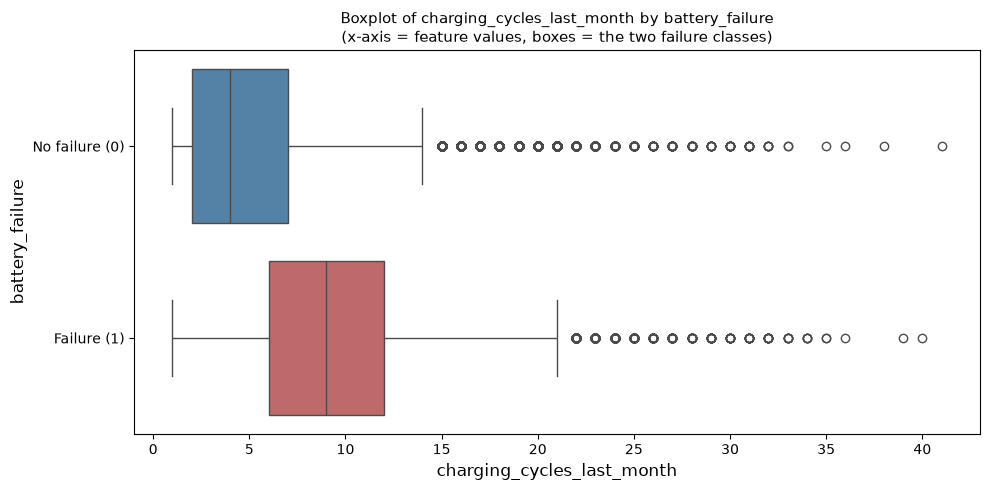

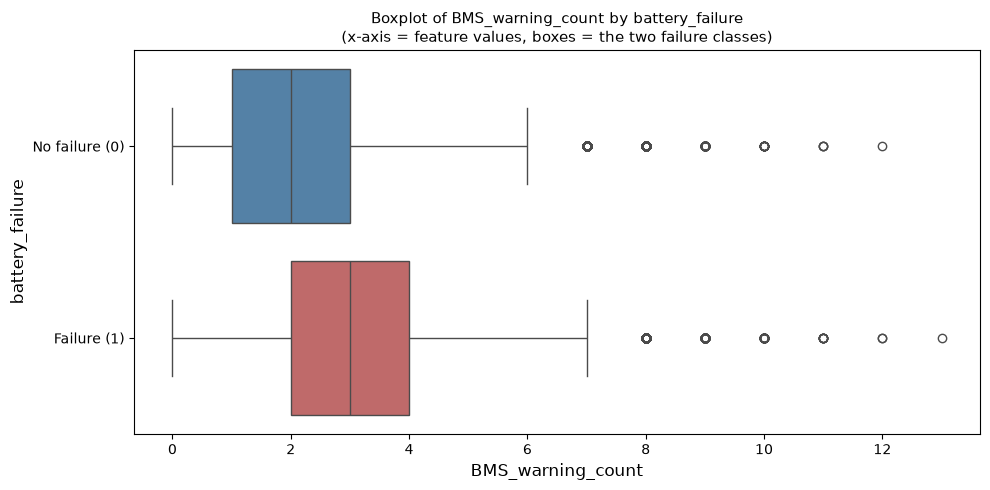

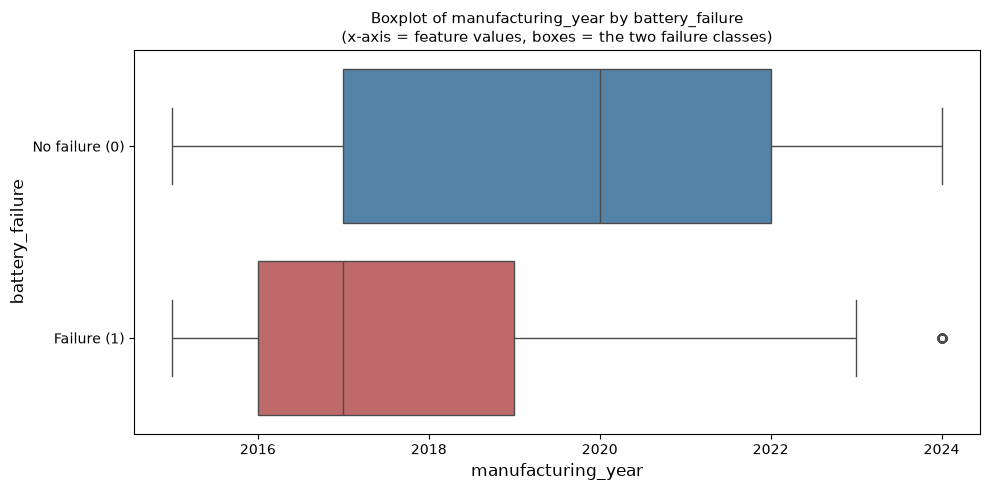

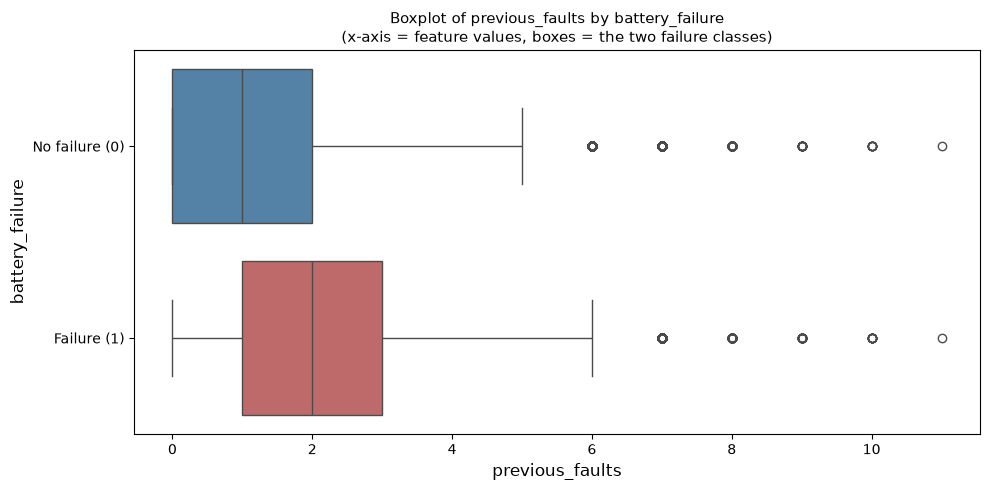

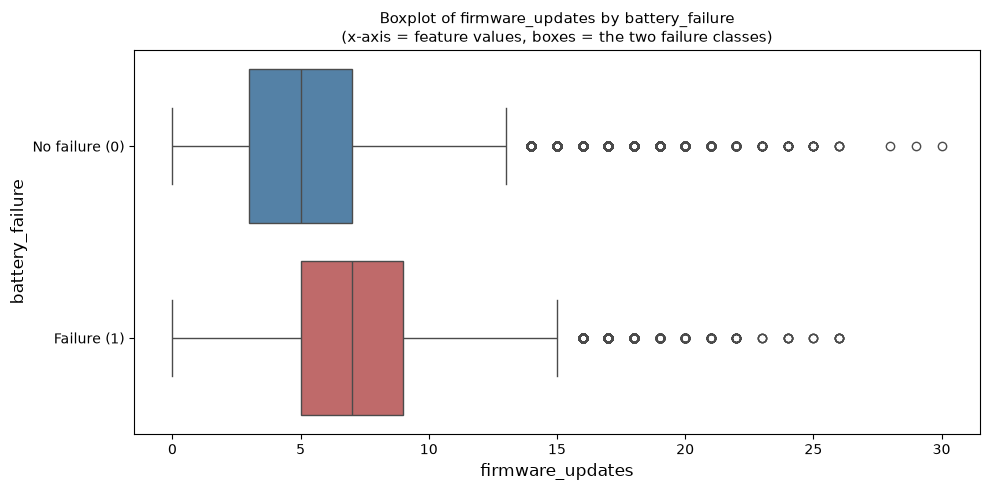

In [60]:

for col in plot_features:
    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(data=df, x=col, y='battery_failure', orient='h',
                     hue='battery_failure', palette=['steelblue', 'indianred'],
                     legend=False)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['No failure (0)', 'Failure (1)'])
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('battery_failure', fontsize=12)
    ax.set_title(f'Boxplot of {col} by battery_failure\n'
                 '(x-axis = feature values, boxes = the two failure classes)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

### Countplots: battery_failure vs each feature
Only features with few unique values are plotted as countplots, coloured by battery_failure.

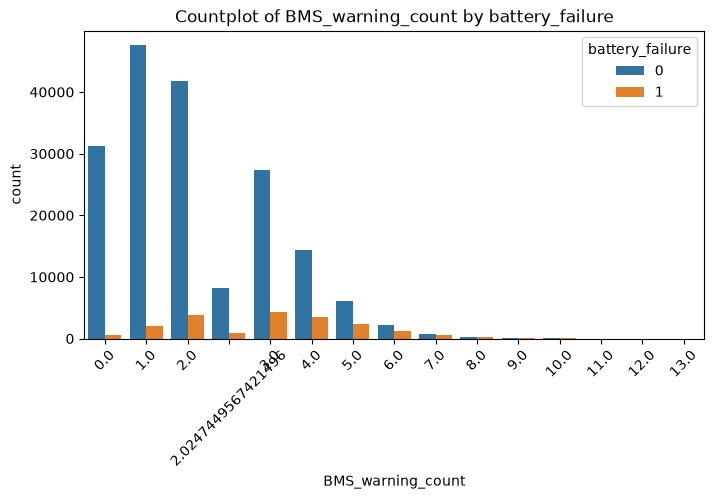

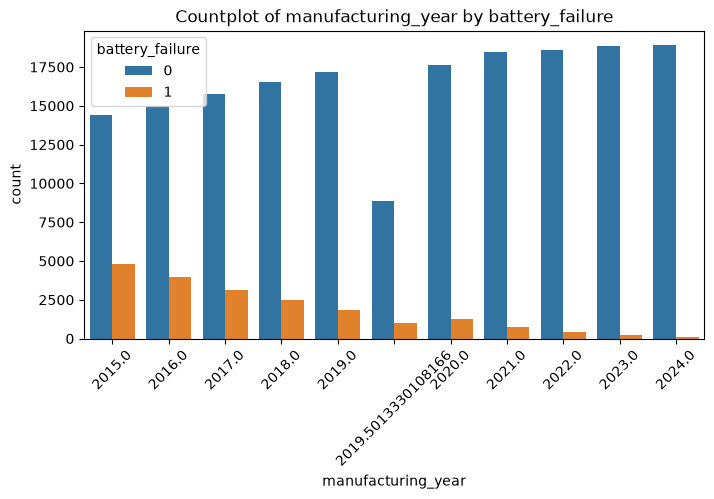

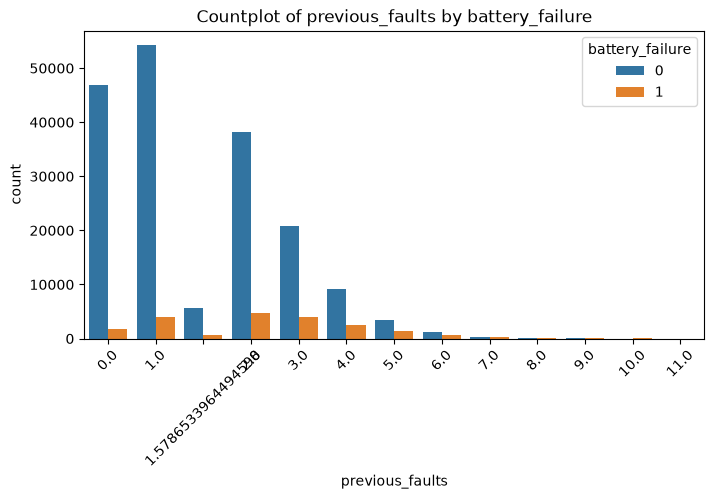

In [38]:
COUNT_LIMIT = 15

for col in plot_features:
    if df[col].nunique() <= COUNT_LIMIT:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, hue='battery_failure')
        plt.title(f'Countplot of {col} by battery_failure')
        plt.xticks(rotation=45)
        plt.show()

### Scatterplots: battery_failure vs each feature

C:\Users\HP USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


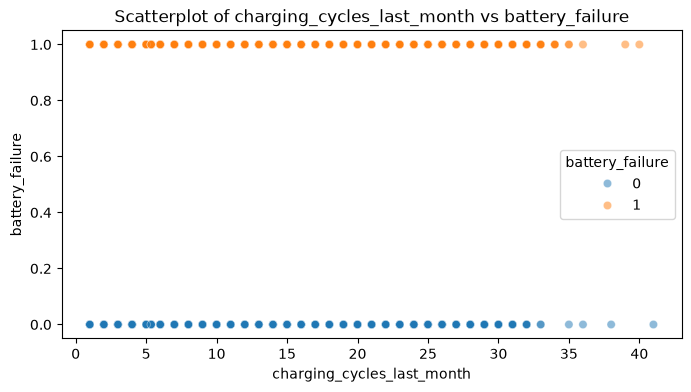

C:\Users\HP USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


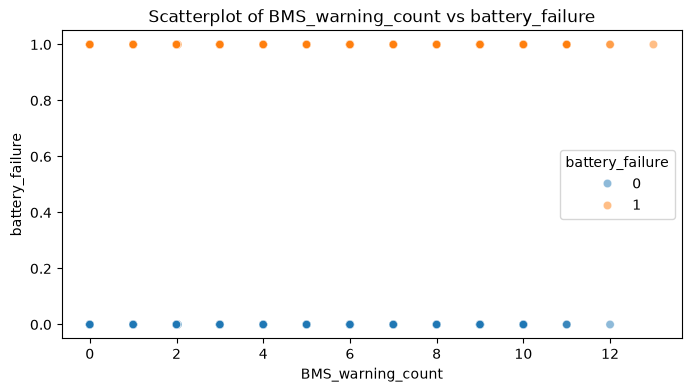

C:\Users\HP USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


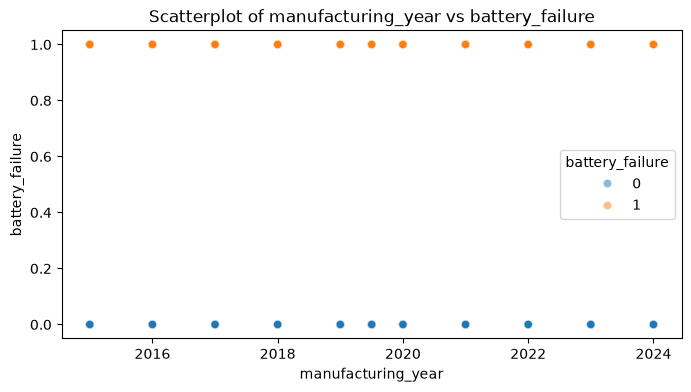

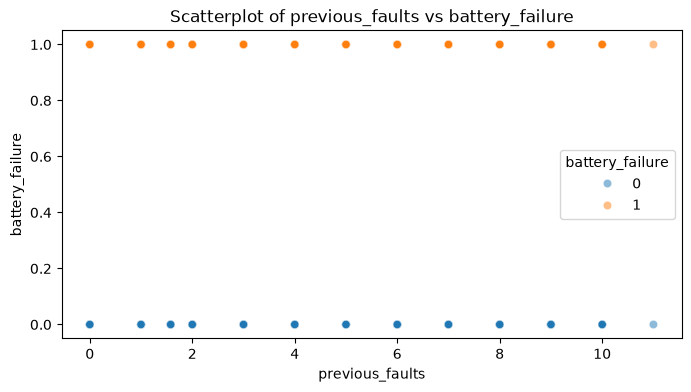

C:\Users\HP USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


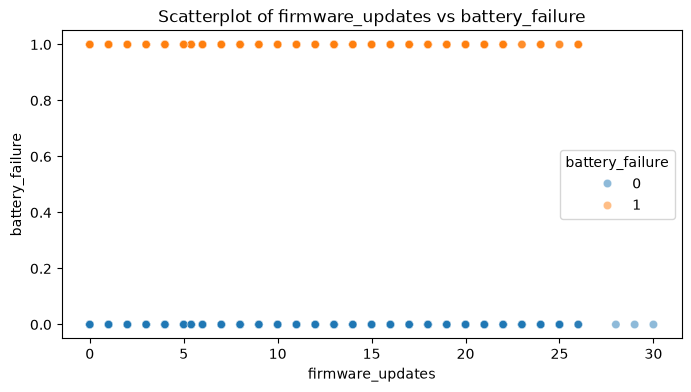

In [39]:
for col in plot_features:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=df, x=col, y='battery_failure', hue='battery_failure', alpha=0.5)
    plt.title(f'Scatterplot of {col} vs battery_failure')
    plt.show()

### ANOVA test (f_classif) on the selected features
One-way ANOVA F-test between each feature and battery_failure. A low p-value (< 0.05) means the feature means differ significantly between failure classes.

In [40]:
from sklearn.feature_selection import f_classif

X_anova = df[plot_features]
y_anova = df['battery_failure']

F_scores, p_values = f_classif(X_anova, y_anova)

anova_results = pd.DataFrame({
    'feature': plot_features,
    'F_score': F_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False)

anova_results['significant'] = anova_results['p_value'] < 0.05
anova_results

,feature,F_score,p_value,significant
0,charging_cycles_last_month,24645.444106,0.0,True
1,BMS_warning_count,16622.554665,0.0,True
2,manufacturing_year,14717.750168,0.0,True
3,previous_faults,9850.910357,0.0,True
4,firmware_updates,6141.709760,0.0,True


In [41]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_resampled, y_resampled = rus.fit_resample(X, y)

## scaling

In [42]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled = StandardScaler().fit_transform(X)

## Neural Networks

In [43]:
import torch

In [44]:
import torch.nn as nn                 
import torch.optim as optim          
from torch.utils.data import DataLoader, TensorDataset


In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42,stratify=y_resampled)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
print(type(y_test))

<class 'pandas.Series'>


In [47]:
# converting numpy to pytorch
X_train_t = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_t = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_t = torch.tensor(X_test_scaled, dtype= torch.float32)
y_test_t = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [48]:
train_ds= TensorDataset(X_train_t,y_train_t)
train_loader= DataLoader(train_ds,batch_size =256,shuffle= True)

## Modelling

In [50]:
class BatteryMLP(nn.Module):
    def __init__(self,in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,32),           nn.ReLU(),nn.Dropout(0.2),
            nn.Linear(32,1)   
        )
    def forward(self, x):
        return self.net(x)

model = BatteryMLP(X_train_t.shape[1])
model    

BatteryMLP(
  (net): Sequential(
    (0): Linear(in_features=35, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [51]:
## Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer= optim.Adam(model.parameters(), lr=0.001)

In [52]:
##Training Loop
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss= criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss+= loss.item()
    print(f"Epoch{epoch+1} -loss:{epoch_loss/len(train_loader):.4f}")


Epoch1 -loss:0.2690
Epoch2 -loss:0.1478
Epoch3 -loss:0.1437
Epoch4 -loss:0.1430
Epoch5 -loss:0.1411
Epoch6 -loss:0.1398
Epoch7 -loss:0.1387
Epoch8 -loss:0.1380
Epoch9 -loss:0.1368
Epoch10 -loss:0.1369
Epoch11 -loss:0.1369
Epoch12 -loss:0.1361
Epoch13 -loss:0.1350
Epoch14 -loss:0.1353
Epoch15 -loss:0.1350
Epoch16 -loss:0.1348
Epoch17 -loss:0.1343
Epoch18 -loss:0.1326
Epoch19 -loss:0.1332
Epoch20 -loss:0.1332
Epoch21 -loss:0.1332
Epoch22 -loss:0.1328
Epoch23 -loss:0.1324
Epoch24 -loss:0.1321
Epoch25 -loss:0.1317
Epoch26 -loss:0.1326
Epoch27 -loss:0.1310
Epoch28 -loss:0.1303
Epoch29 -loss:0.1306
Epoch30 -loss:0.1304
Epoch31 -loss:0.1312
Epoch32 -loss:0.1293
Epoch33 -loss:0.1299
Epoch34 -loss:0.1297
Epoch35 -loss:0.1298
Epoch36 -loss:0.1286
Epoch37 -loss:0.1287
Epoch38 -loss:0.1277
Epoch39 -loss:0.1282
Epoch40 -loss:0.1276
Epoch41 -loss:0.1276
Epoch42 -loss:0.1267
Epoch43 -loss:0.1266
Epoch44 -loss:0.1278
Epoch45 -loss:0.1267
Epoch46 -loss:0.1252
Epoch47 -loss:0.1260
Epoch48 -loss:0.1257
E

This shows that with every epoch the traing model gets better as loss decresses

In [53]:
## Evaluation
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t))
    pred = (probs > 0.5).float()
accuracy = (pred == y_test_t).float().mean().item()
print(f"Test accuracy:{accuracy:.4f}")

Test accuracy:0.9438


In [54]:
print("original columns",df.shape[1])
print("Columns in X :",X.shape[1])
print(X.columns.tolist())

original columns 70
Columns in X : 35
['capacity_loss_percent', 'battery_health_percent', 'state_of_health', 'aging_score', 'cell_voltage_std', 'charge_efficiency', 'cycle_count', 'odometer_km', 'voltage_imbalance', 'charging_quality_score', 'thermal_runaway_risk', 'thermal_health_score', 'daily_distance', 'internal_resistance', 'charging_cycles_last_month', 'remaining_capacity', 'average_trip_distance', 'battery_stress_index', 'BMS_warning_count', 'cooling_system_health', 'fast_charge_ratio', 'slow_charge_ratio', 'vehicle_age_years', 'manufacturing_year', 'home_charging_ratio', 'predicted_remaining_life_cycles', 'average_charge_power_kw', 'previous_faults', 'discharge_efficiency', 'overnight_charging_ratio', 'average_charging_time', 'firmware_updates', 'cell_voltage_avg', 'cell_temperature_avg', 'temperature_variance']


## Metrics

In [55]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
fitted_models=[model]

metrics_results=[]

for m in fitted_models:
    model_name=m.__class__.__name__

    m.eval()
    with torch.no_grad():
        probs = torch.sigmoid(m(X_test_t))
        y_pred = (probs > 0.5).float()

    cm=confusion_matrix(y_test_t,y_pred)
    accuracy=accuracy_score(y_test_t,y_pred)
    precision=precision_score(y_test_t,y_pred)
    recall=recall_score(y_test_t,y_pred)


    metrics_results.append({
        "Model": model_name,
        "Confusion Matrix":cm.tolist(),
        "Accuracy":round(accuracy,4),
        "Precision":round(precision,4),
        "Recall":round(recall,4)
    })

result_df=pd.DataFrame(metrics_results)

print("---Model Performance Comparison---")
print(result_df.to_string(index=False))



---Model Performance Comparison---
     Model           Confusion Matrix  Accuracy  Precision  Recall
BatteryMLP [[3685, 300], [148, 3836]]    0.9438     0.9275  0.9629


In [56]:
from sklearn.datasets import load_iris
from sklearn.metrics import ConfusionMatrixDisplay

In [61]:
iris=load_iris()
X=iris.data
y=iris.target

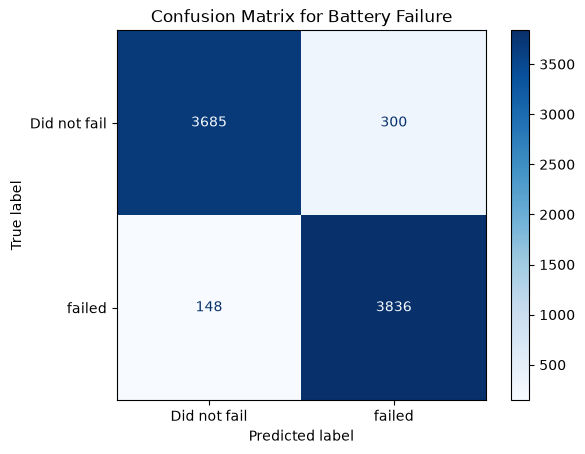

In [63]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels =['Did not fail','failed'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Battery Failure')
plt.show()